# In Class May 19

In [1]:
# importing libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### Importing the data

In [2]:
# importing mnist data from keras
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


### Visualizing the data

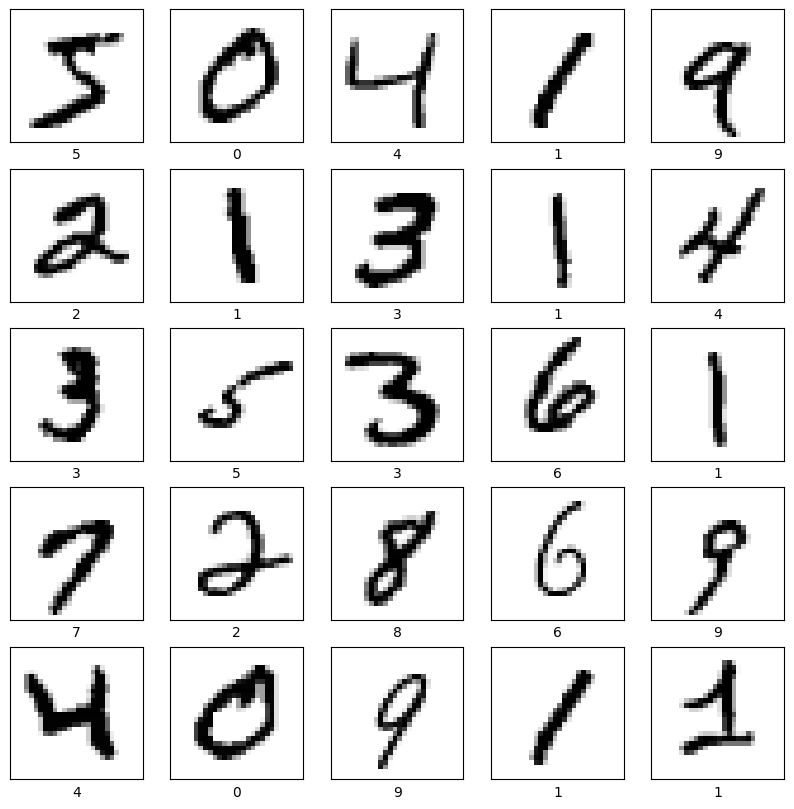

In [3]:
# visualize some of the data
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.cm.binary)
    plt.xlabel(y_train[i])
plt.show()

### Preprocessing data for MLP

In [4]:

# Normalize pixel values to 0–1
X_train_norm = X_train / 255.0   # scale pixel values from 0–255 → 0–1
X_test_norm = X_test / 255.0     # apply same scaling to test data

# Flatten images for the MLP
X_train_flat = X_train_norm.reshape(X_train.shape[0], -1)  # # reshape from (60000, 28, 28) → (60000, 784)
X_test_flat = X_test_norm.reshape(X_test.shape[0], -1)     # same transformation for test images

print(X_train_flat.shape)
print(X_test_flat.shape)

(60000, 784)
(10000, 784)


### Building the MLP model

In [5]:
# Define the MLP baseline model
mlp_model = keras.Sequential([
    layers.Input(shape=(784,)),                 # input is a flattened image (784 pixels)
    layers.Dense(128, activation="relu"),       # hidden layer with 128 neurons (learns patterns)
    layers.Dense(64, activation="relu"),        # second hidden layer for more complex patterns
    layers.Dense(10, activation="softmax"),     # output layer (10 classes for digits 0–9)
])

# Compile the MLP model
mlp_model.compile(
    optimizer="adam",                           # optimization algorithm for training
    loss="sparse_categorical_crossentropy",     # loss for multi-class classification with integer labels
    metrics=["accuracy"]                        # track accuracy during training
)

# summary of the MLP model architecture
mlp_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# train the MLP model
history_mlp = mlp_model.fit(
    X_train_flat,                               # flattened training images
    y_train,                                    # labels (0–9)
    epochs=5,                                   # number of training passes through data
    batch_size=128,                             # number of samples per training step
    validation_split=0.1                        # use 10% of training data for validation
)

# evaluate the MLP model on test data
test_loss_mlp, test_acc_mlp = mlp_model.evaluate(X_test_flat, y_test, verbose=2)
print(f"MLP Test accuracy: {test_acc_mlp:.4f}")

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8972 - loss: 0.3641 - val_accuracy: 0.9590 - val_loss: 0.1496
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9549 - loss: 0.1522 - val_accuracy: 0.9682 - val_loss: 0.1134
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9688 - loss: 0.1059 - val_accuracy: 0.9750 - val_loss: 0.0929
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9760 - loss: 0.0804 - val_accuracy: 0.9758 - val_loss: 0.0874
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9810 - loss: 0.0624 - val_accuracy: 0.9783 - val_loss: 0.0821
313/313 - 1s - 2ms/step - accuracy: 0.9746 - loss: 0.0884
MLP Test accuracy: 0.9746


### Preparing data for CNN

In [11]:
X_train_cnn = X_train_norm[..., np.newaxis]  # add channel dimension → (60000, 28, 28, 1)
X_test_cnn = X_test_norm[..., np.newaxis]    # same for test data

print("CNN input shape:", X_train_cnn.shape)  # confirm new shape for CNN

CNN input shape: (60000, 28, 28, 1)


### Building the CNN model

In [12]:
# define the model

cnn_model = models.Sequential([
    layers.Input(shape=(28,28,1)),                # input is 28x28 image with 1 channel (grayscale)
    layers.Conv2D(32, (3,3), activation="relu"),  # apply 32 filters to detect local patterns (edges, curves)
    layers.MaxPooling2D((2,2)),                   # reduce spatial size (summarize important features)
    layers.Flatten(),                             # convert feature maps into a vector
    layers.Dense(64, activation="relu"),          # combine extracted features into higher-level patterns
    layers.Dense(10, activation="softmax"),       # output probabilities for digits 0–9
])

In [13]:
# compile the model
cnn_model.compile(
    optimizer="adam",                             # optimization algorithm
    loss="sparse_categorical_crossentropy",       # loss for multi-class classification
    metrics=["accuracy"]                          # track accuracy during training
)

# train the model
cnn_history = cnn_model.fit(
    X_train_cnn,                                  # image data with spatial structure
    y_train,                                      # labels (correct digits)
    epochs=5,                                     # number of passes through the dataset
    validation_split=0.1                          # use 10% of training data for validation
)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.9470 - loss: 0.1814 - val_accuracy: 0.9787 - val_loss: 0.0765
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step - accuracy: 0.9803 - loss: 0.0631 - val_accuracy: 0.9858 - val_loss: 0.0531
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step - accuracy: 0.9870 - loss: 0.0425 - val_accuracy: 0.9888 - val_loss: 0.0481
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 43s 18ms/step - accuracy: 0.9905 - loss: 0.0306 - val_accuracy: 0.9862 - val_loss: 0.0534
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step - accuracy: 0.9937 - loss: 0.0203 - val_accuracy: 0.9880 - val_loss: 0.0470


### Evaluating the CNN model

In [14]:
# Evaluate the CNN on test data
cnn_loss, cnn_acc = cnn_model.evaluate(X_test_cnn, y_test)  # evaluate on unseen test data
print("CNN Test Accuracy:", cnn_acc)                        # report final test accuracy

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9863 - loss: 0.0431
CNN Test Accuracy: 0.986299991607666


### MLP vs CNN model

In [15]:
# Compare the CNN's performance to the MLP baseline
print(f"MLP Test accuracy: {test_acc_mlp:.4f}")
print(f"CNN Test accuracy: {cnn_acc:.4f}")


MLP Test accuracy: 0.9746
CNN Test accuracy: 0.9863


### Visualizing model training

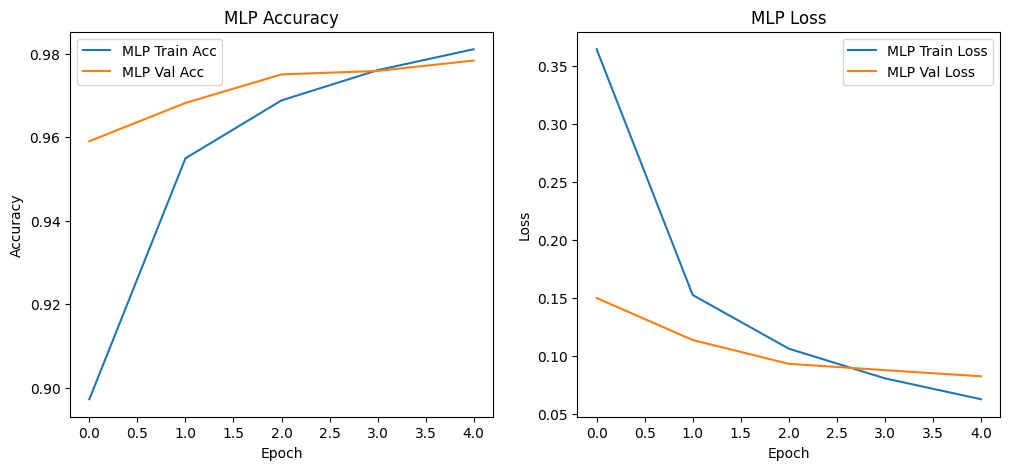

In [16]:
# Plot training history for MLP (accuracy over epochs and loss over epochs)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_mlp.history['accuracy'], label='MLP Train Acc')
plt.plot(history_mlp.history['val_accuracy'], label='MLP Val Acc')
plt.title('MLP Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_mlp.history['loss'], label='MLP Train Loss')
plt.plot(history_mlp.history['val_loss'], label='MLP Val Loss')
plt.title('MLP Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


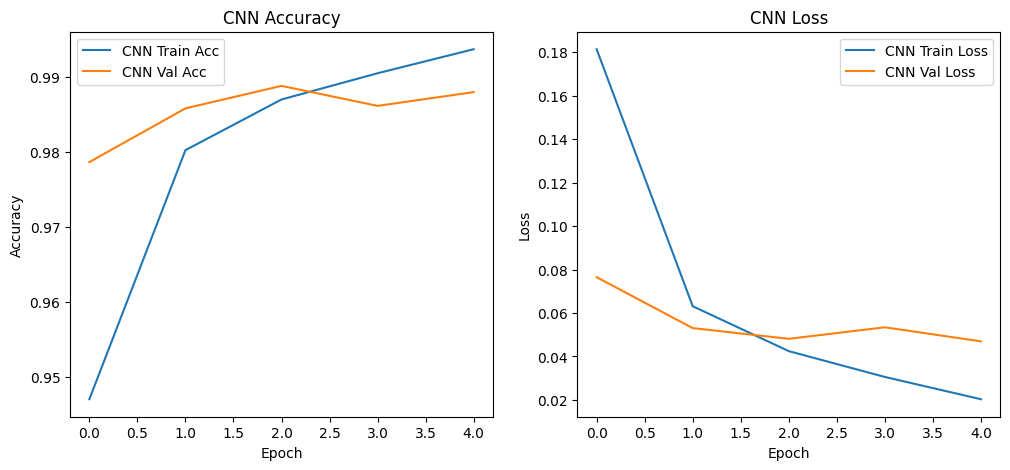

In [17]:
# plot training history for CNN (accuracy over epochs and loss over epochs)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['accuracy'], label='CNN Train Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['loss'], label='CNN Train Loss')
plt.plot(cnn_history.history['val_loss'], label='CNN Val Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


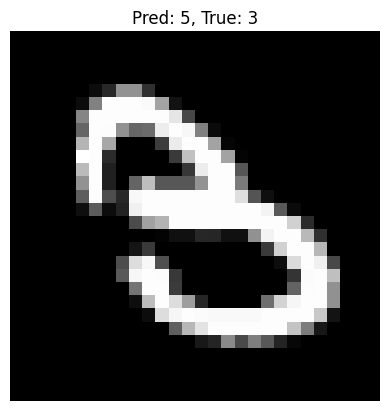

In [18]:
# Get predictions
cnn_predictions = cnn_model.predict(X_test_cnn)

# Find a misclassified example
for i in range(len(X_test)):
    pred = np.argmax(cnn_predictions[i])  # predicted class

    if pred != y_test[i]:                 # compare to true label
        plt.imshow(X_test[i], cmap="gray")
        plt.title(f"Pred: {pred}, True: {y_test[i]}")
        plt.axis("off")
        break

### How well do the models perform if we rotate the images?

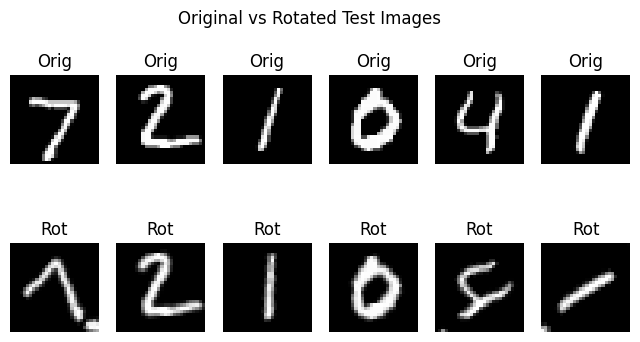

In [19]:
# Visualize rotated test images (to see what changed)

rotation_layer_eval = tf.keras.layers.RandomRotation(0.15)

X_test_rot_eval_cnn = rotation_layer_eval(X_test_cnn, training=True)

plt.figure(figsize=(8, 4))

for i in range(6):
    # Original
    plt.subplot(2, 6, i + 1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title("Orig")
    plt.axis('off')

    # Rotated
    plt.subplot(2, 6, i + 7)
    plt.imshow(X_test_rot_eval_cnn[i].numpy().squeeze(), cmap='gray')
    plt.title("Rot")
    plt.axis('off')

plt.suptitle("Original vs Rotated Test Images")
plt.show()

In [20]:
# Flatten rotated images for MLP
X_test_rot_eval_flat = X_test_rot_eval_cnn.numpy().reshape(X_test.shape[0], -1)

# Evaluate original models on rotated data
mlp_rot_eval_loss, mlp_rot_eval_acc = mlp_model.evaluate(X_test_rot_eval_flat, y_test)
cnn_rot_eval_loss, cnn_rot_eval_acc = cnn_model.evaluate(X_test_rot_eval_cnn, y_test)

print("MLP accuracy (original test):", test_acc_mlp)
print("MLP accuracy (rotated test):", mlp_rot_eval_acc)

print("CNN accuracy (original test):", cnn_acc)
print("CNN accuracy (rotated test):", cnn_rot_eval_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6895 - loss: 1.5066
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7665 - loss: 1.2205
MLP accuracy (original test): 0.9746000170707703
MLP accuracy (rotated test): 0.6894999742507935
CNN accuracy (original test): 0.986299991607666
CNN accuracy (rotated test): 0.7664999961853027


### New models trained with data augmentation (random rotations)

In [21]:
# Create rotated datasets for retraining models
rotation_layer_train = tf.keras.layers.RandomRotation(0.15)

X_train_rot_train_cnn = rotation_layer_train(X_train_cnn, training=True)  # rotated training images for CNN
X_test_rot_train_cnn = rotation_layer_train(X_test_cnn, training=True)    # rotated test images for CNN

# Flatten rotated datasets for MLP
X_train_rot_train_flat = X_train_rot_train_cnn.numpy().reshape(X_train.shape[0], -1)
X_test_rot_train_flat = X_test_rot_train_cnn.numpy().reshape(X_test.shape[0], -1)

### Use the code cell below to build, train and evaluate a CNN model using the rotated data (X_train_rot_train_cnn and X_test_rot_train_cnn)

In [22]:
# Define the CNN model trained on rotated data
cnn_rot_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),                 # input is a 28x28 grayscale image
    layers.Conv2D(32, (3, 3), activation="relu"),    # detect local image patterns
    layers.MaxPooling2D((2, 2)),                     # reduce spatial dimensions
    layers.Conv2D(64, (3, 3), activation="relu"),    # learn more complex patterns
    layers.MaxPooling2D((2, 2)),                     # reduce size again
    layers.Flatten(),                                # convert feature maps into vector
    layers.Dense(64, activation="relu"),             # hidden layer
    layers.Dense(10, activation="softmax")           # output layer for digits 0-9
])

# Compile the CNN model
cnn_rot_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train the CNN model on rotated data
history_cnn_rot = cnn_rot_model.fit(
    X_train_rot_train_cnn,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Evaluate the CNN model on rotated test data
cnn_rot_loss, cnn_rot_acc = cnn_rot_model.evaluate(
    X_test_rot_train_cnn,
    y_test,
    verbose=0
)

print(f"CNN Rotated Test accuracy: {cnn_rot_acc:.4f}")

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 52s 29ms/step - accuracy: 0.9063 - loss: 0.2965 - val_accuracy: 0.9647 - val_loss: 0.1170
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 51s 30ms/step - accuracy: 0.9645 - loss: 0.1150 - val_accuracy: 0.9763 - val_loss: 0.0815
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 51s 30ms/step - accuracy: 0.9746 - loss: 0.0807 - val_accuracy: 0.9790 - val_loss: 0.0746
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 52s 31ms/step - accuracy: 0.9808 - loss: 0.0610 - val_accuracy: 0.9763 - val_loss: 0.0777
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 83s 31ms/step - accuracy: 0.9858 - loss: 0.0445 - val_accuracy: 0.9815 - val_loss: 0.0667
CNN Rotated Test accuracy: 0.9767


### Use the code cell below to build, train and evaluate an MLP model using the rotated data (X_train_rot_train_flat and X_test_rot_train_flat)

In [23]:
# Define the MLP model trained on rotated data
mlp_rot_model = keras.Sequential([
    layers.Input(shape=(784,)),                  # input is a flattened 28x28 image
    layers.Dense(128, activation="relu"),        # first hidden layer learns patterns
    layers.Dense(64, activation="relu"),         # second hidden layer combines patterns
    layers.Dense(10, activation="softmax")       # output probabilities for digits 0-9
])

# Compile the MLP model
mlp_rot_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train the MLP model on rotated flattened data
history_mlp_rot = mlp_rot_model.fit(
    X_train_rot_train_flat,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Evaluate the MLP model on rotated flattened test data
mlp_rot_loss, mlp_rot_acc = mlp_rot_model.evaluate(
    X_test_rot_train_flat,
    y_test,
    verbose=0
)

print(f"MLP Rotated Test accuracy: {mlp_rot_acc:.4f}")

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8650 - loss: 0.4438 - val_accuracy: 0.9318 - val_loss: 0.2261
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9328 - loss: 0.2198 - val_accuracy: 0.9470 - val_loss: 0.1730
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9493 - loss: 0.1626 - val_accuracy: 0.9568 - val_loss: 0.1417
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9602 - loss: 0.1279 - val_accuracy: 0.9582 - val_loss: 0.1378
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9666 - loss: 0.1060 - val_accuracy: 0.9603 - val_loss: 0.1346
MLP Rotated Test accuracy: 0.9552


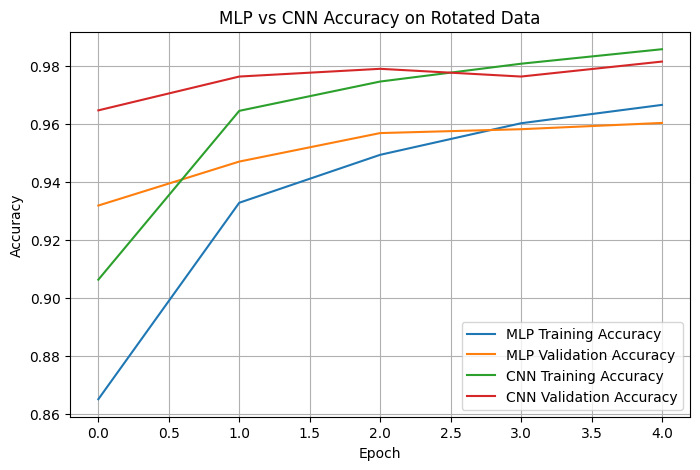

In [25]:

# Plot training and validation accuracy for MLP and CNN
plt.figure(figsize=(8, 5))

plt.plot(history_mlp_rot.history["accuracy"], label="MLP Training Accuracy")
plt.plot(history_mlp_rot.history["val_accuracy"], label="MLP Validation Accuracy")
plt.plot(history_cnn_rot.history["accuracy"], label="CNN Training Accuracy")
plt.plot(history_cnn_rot.history["val_accuracy"], label="CNN Validation Accuracy")

plt.title("MLP vs CNN Accuracy on Rotated Data")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

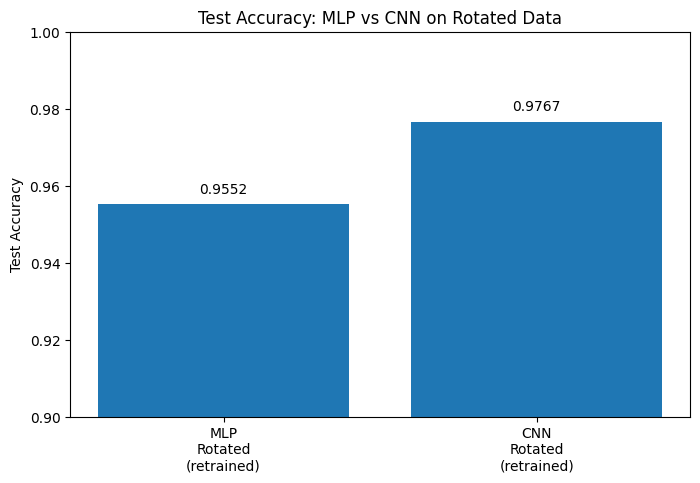

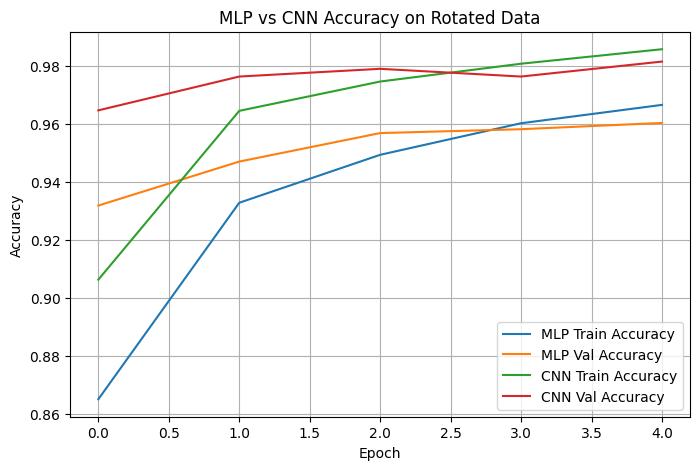

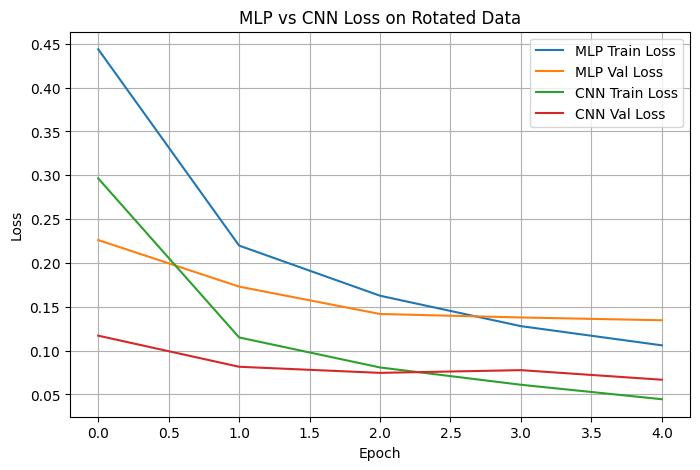

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1. Bar chart of test accuracy
# -----------------------------

model_names = [
    "MLP\nRotated\n(retrained)",
    "CNN\nRotated\n(retrained)"
]

test_accuracies = [
    mlp_rot_acc,
    cnn_rot_acc
]

plt.figure(figsize=(8, 5))

bars = plt.bar(model_names, test_accuracies)

plt.title("Test Accuracy: MLP vs CNN on Rotated Data")
plt.ylabel("Test Accuracy")
plt.ylim(0.90, 1.00)

# Add values above bars
for bar, acc in zip(bars, test_accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f"{acc:.4f}",
        ha="center",
        va="bottom"
    )

plt.show()


# -----------------------------------------
# 2. Accuracy curves for MLP and CNN
# -----------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(history_mlp_rot.history["accuracy"], label="MLP Train Accuracy")
plt.plot(history_mlp_rot.history["val_accuracy"], label="MLP Val Accuracy")
plt.plot(history_cnn_rot.history["accuracy"], label="CNN Train Accuracy")
plt.plot(history_cnn_rot.history["val_accuracy"], label="CNN Val Accuracy")

plt.title("MLP vs CNN Accuracy on Rotated Data")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


# -----------------------------------------
# 3. Loss curves for MLP and CNN
# -----------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(history_mlp_rot.history["loss"], label="MLP Train Loss")
plt.plot(history_mlp_rot.history["val_loss"], label="MLP Val Loss")
plt.plot(history_cnn_rot.history["loss"], label="CNN Train Loss")
plt.plot(history_cnn_rot.history["val_loss"], label="CNN Val Loss")

plt.title("MLP vs CNN Loss on Rotated Data")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### Using the markdown cell below evaluate the performance of the MLP vs the CNN. Use graphs and metrics to support your evaluation.

The CNN performed better than the MLP on the rotated digit data. The CNN had a test accuracy of 0.9767, while the MLP had a test accuracy of 0.9552. This means the CNN performed about 2.15 percentage points better on the test set.

The accuracy graph shows that both models improved over the 5 epochs, but the CNN stayed above the MLP for most of the training process. The CNN also ended with a higher validation accuracy, which shows that it generalized better to unseen validation data.

The loss graph also supports this conclusion. The CNN had lower training and validation loss than the MLP by the end of training. This means the CNN was making more accurate and confident predictions overall.

The main reason the CNN performed better is because it preserves the spatial structure of the images. Since rotated digits still have important visual features like curves, edges, and shapes, the CNN can learn those patterns through convolutional layers. The MLP uses flattened data, so it loses the 2D pixel relationships in the image. Therefore, the CNN is the stronger model for this rotated image classification task.
